## Allee effect demo

This workbook investigates the impact of starting density of the two auxotrophic populations on the long-term composition of the two-species auxotrophy model in the absence of external amino acids. Final outcome is Fig. S1 of the manuscript.

In [4]:
#Import packages used
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import scipy.optimize

import sys
sys.path.append('C:\\Users\\bi1ojm\\Documents\\GitHub\\FeedOrFold\\EOsimSuite\\')
from EOsimsuite import EOsimsuite as EOsim

In [5]:
#Sensitivity function - rs are resource concs, specInd is the index of the species under consideration, C is the consumption matrix, delW is the resource values and D is the mortality rate
def sensFunc(rs,specInd,EOparams):
    Kms = EOparams['Kms']
    Vmax = EOparams['Vmax']
    
    monodG = rs[-1]/(rs[-1]+Kms[specInd,-1])
    monodA = rs[specInd]/(rs[specInd]+Kms[specInd,specInd])

    sens = Vmax*monodA*monodG

    return sens

#Gradient of the sensitivity function in the resource space
def gradSensFunc(rs,specInd,EOparams):
    Kms = EOparams['Kms']
    Vmax = EOparams['Vmax']
    
    sensGrad = np.zeros(rs.shape)
    
    monodG = rs[-1]/(rs[-1]+Kms[specInd,-1])
    dMonodG = Kms[-1,-1]/(rs[-1] + Kms[specInd,-1])**2
    
    monodA = rs[specInd]/(rs[specInd] + Kms[specInd,specInd])
    dMonodA = Kms[specInd,specInd]/(rs[specInd] + Kms[specInd,specInd])**2
    
    sensGrad[-1] = dMonodG*monodA*Vmax
    sensGrad[specInd] = dMonodA*monodG*Vmax
    
    return sensGrad

#Impact function for a single species
def impactFunc(rs,specInd,EOparams):
    Kms = EOparams['Kms']
    Vmax = EOparams['Vmax']
    Ys = EOparams['Ys']
    Cs = EOparams['Cs']
    
    impact = np.zeros(rs.shape)
    
    monodG = rs[-1]/(rs[-1]+Kms[specInd,-1])
    monodA = rs[specInd]/(rs[specInd]+Kms[specInd,specInd])

    for i in range(len(rs)):
        if i == specInd: #If this is the missing amino acid
            impact[i] = -(Vmax/Ys[specInd,i])*monodG*monodA #Amount of amino acid being used by the strain at this time and converted to biomass
        elif i == len(rs)-1: #If this is the glucose
            impact[i] = -(Vmax/Ys[specInd,i])*monodG*monodA - sum(Cs[specInd,:-1])*Vmax*monodG #first term is amount of glucose being converted to biomas, second is amount being converted to amino acids
        else: #If this is any of the (potentially) secreted amino acids
            impact[i] = Cs[specInd,i]*Vmax*monodG

    return impact

def instInteract(rs,alphInd,betInd,EOparams):
    return(np.dot(impactFunc(rs,betInd,EOparams),gradSensFunc(rs,alphInd,EOparams)))

def intrinsicGR(rs,alphInd,EOparams,sysParams):
    return(np.dot(gradSensFunc(rs,alphInd,EOparams),sysParams['D']*(sysParams['rIn']-rs)))

In [6]:
#2-species function test
Kms = np.array([[0.8,-1,1.8],[-1,1.4,0.7]]) #Proline auxotroph then tryptophan auxotroph
Ys = np.array([[5,0,1],[0,10,1]])
Cs = np.array([[0,0.025,-1],[0.05,0,-1]]) #Rate at which glucose is converted into relevant amino acids
Vmax = 0.4

EOparams = {'Kms':Kms,'Ys':Ys,'Cs':Cs,'Vmax':Vmax}

DilRate = 0.01

proConc = 0.
tryConc = 0.
        
rIn = np.array([proConc,tryConc,2])
sysParams = {'rIn':rIn}

Step through a 100x100 grid of starting densities for the two populations and score coexistence outcomes depending on whether neither, one or both populations coexist in the long-term.

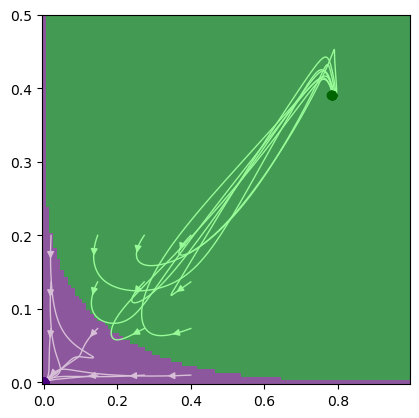

In [13]:
#Maximal starting abundances of the two auxotrophs
minW = 0
maxW = 0.5
minP = 0
maxP = 1

sampPtsW = 100
sampPtsP = 100

wList = np.linspace(minW,maxW,sampPtsW)
pList = np.linspace(minP,maxP,sampPtsP)

wField, pField = np.meshgrid(wList, pList)

wStep = wField[0,1] - wField[0,0]
pStep = pField[1,0] - pField[0,0]

imgStore = np.zeros((sampPtsP,sampPtsW))

r0 = np.array([0,0,2])

for wInd in range(sampPtsW):
    for pInd in range(sampPtsP):
        B0 = np.array([pField[pInd,wInd],wField[pInd,wInd]])
        chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,r0)
        chemSim.set_timeSettings(tSpan = [0,2000], dt=0.1)
        chemSim.set_dilSettings(D=DilRate,transT=0.1)
        chemSim.set_instInteract(instInteract)
        chemSim.set_intrinsicGR(intrinsicGR)
        chemSim.simEOmodel('Chemostat')

        if sum(chemSim.specTimeseries[:,-1] < 0.001) == 0:
            imgStore[wInd,pInd] = 1 #Flip normal indices for image-based coordinate space
        elif sum(chemSim.specTimeseries[:,-1] < 0.001) == 2:
            imgStore[wInd,pInd] = 0
        else:
            imgStore[wInd,pInd] = 2 #Shouldn't happen, but score just in case...

plt.imshow(imgStore,cmap='PRGn',extent=[-pStep/2,maxP-pStep/2,-wStep/2,maxW-wStep/2],origin='lower',vmin=-0.25,vmax=1.25)

ax1 = plt.gca()

minW = 0.01
maxW = 0.2
minP = 0.02
maxP = 0.4

sampPtsW = 4
sampPtsP = 4

wList = np.linspace(minW,maxW,sampPtsW)
pList = np.linspace(minP,maxP,sampPtsP)

wField, pField = np.meshgrid(wList, pList)

wStep = wField[0,1] - wField[0,0]
pStep = pField[1,0] - pField[0,0]

t1=100
t2=200

#Generate example trajectories showing bistability of system
for wInd in range(sampPtsW):
    for pInd in range(sampPtsP):
        B0 = np.array([pField[pInd,wInd],wField[pInd,wInd]])
        chemSim = EOsim(impactFunc,sensFunc,EOparams,sysParams,B0,r0)
        chemSim.set_timeSettings(tSpan = [0,2000], dt=0.1)
        chemSim.set_dilSettings(D=DilRate,transT=0.1)
        chemSim.set_instInteract(instInteract)
        chemSim.set_intrinsicGR(intrinsicGR)
        chemSim.simEOmodel('Chemostat')

        if sum(chemSim.specTimeseries[:,-1]) < 0.001:
            plt.plot(chemSim.specTimeseries[0,:],chemSim.specTimeseries[1,:],lw=1,color='thistle')
            plt.plot(chemSim.specTimeseries[0,-1],chemSim.specTimeseries[1,-1],'o',color='indigo')
            ax1.annotate("", xytext=(chemSim.specTimeseries[0,t1], chemSim.specTimeseries[1,t1]), 
                xy=(chemSim.specTimeseries[0,t2], chemSim.specTimeseries[1,t2]),
                arrowprops=dict(arrowstyle="-|>",color='thistle'))
        else:
            plt.plot(chemSim.specTimeseries[0,:],chemSim.specTimeseries[1,:],lw=1,color='palegreen')
            plt.plot(chemSim.specTimeseries[0,-1],chemSim.specTimeseries[1,-1],'o',color='darkgreen')
            ax1.annotate("", xytext=(chemSim.specTimeseries[0,t1], chemSim.specTimeseries[1,t1]), 
                xy=(chemSim.specTimeseries[0,t2], chemSim.specTimeseries[1,t2]),
                arrowprops=dict(arrowstyle="-|>",color='palegreen'))

plt.gca().set_aspect(2)
plt.gca().set_ylim([-0.0025,0.5])

plt.savefig("G:\\My Drive\\Writing\\Papers\\Mutualismo\\Figures\\PDFs\\CoexistenceBasins.pdf")